# Train on Kubeflow

Goal:

- Train a YOLO model to detect license plates.
- Run in a Kubeflow Notebook on EKS (CPU node).
- Pull the raw dataset with `dvc pull`.
- Export the trained model to `s3://<bucket>/models/`.


## Environment

Install dependencies.


In [5]:
# pip install
%pip install -q -U ultralytics torch torchvision onnx onnxslim "dvc[s3]"

Note: you may need to restart the kernel to use updated packages.


Inspect the runtime environment.


In [6]:
import os
import subprocess
import sys
from pathlib import Path

import torch
import torchvision
import ultralytics

# Repo root
ROOT = Path(
    subprocess.run(
        ["git", "rev-parse", "--show-toplevel"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
)

# helpers live in train-job/src
sys.path.insert(0, str(ROOT / "train-job"))

# define path
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RUNS = ROOT / "runs"
MODELS = ROOT / "models"

# create dir
for d in (RAW, PROCESSED, RUNS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

# get bucket
BUCKET = os.environ.get("BUCKET", "kubeflow-yolo-dev-099139718958")
REGION = os.environ.get("AWS_REGION", "ca-central-1")

# bucket keys
S3_DVCSTORE = f"s3://{BUCKET}/dvcstore"
S3_MODELS = f"s3://{BUCKET}/models"

# get device
DEVICE = 0 if torch.cuda.is_available() else "cpu"
# device tag
device_tag = "gpu" if torch.cuda.is_available() else "cpu"

# print environment info
print("python         ", sys.version.split()[0])
print("torch          ", torch.__version__)
print("torchvision    ", torchvision.__version__)
print("ultralytics    ", ultralytics.__version__)
print("cuda           ", torch.cuda.is_available())
print("device         ", device_tag)
print("region         ", REGION)
print("bucket         ", BUCKET)
print("root           ", ROOT)

python          3.12.13
torch           2.13.0+cu130
torchvision     0.28.0+cu130
ultralytics     8.4.124
cuda            False
device          cpu
region          ca-central-1
bucket          kubeflow-yolo-dev-099139718958
root            /home/jovyan/kubeflow-yolo


---

## Data processing

Download the raw dataset from S3.

`data/raw.dvc` pins the dataset version. DVC stores objects by hash, so the
`.dir` manifest maps each hash back to its filename.


In [7]:
import json
from concurrent.futures import ThreadPoolExecutor

import boto3
import yaml

s3 = boto3.client("s3", region_name=REGION)


def dvc_key(md5: str) -> str:
    """DVC stores an object at files/md5/<first 2 chars>/<rest>."""
    return f"dvcstore/files/md5/{md5[:2]}/{md5[2:]}"


def download_raw(dvc_file, dest):
    """Restore a dvc-tracked directory from S3 using its .dir manifest."""
    out = yaml.safe_load(dvc_file.read_text())["outs"][0]

    # the .dir object lists {"md5": ..., "relpath": ...} for every file
    manifest = json.loads(
        s3.get_object(Bucket=BUCKET, Key=dvc_key(out["md5"]))["Body"].read()
    )

    def fetch(entry):
        target = dest / entry["relpath"]
        if target.exists():
            return 0
        target.parent.mkdir(parents=True, exist_ok=True)
        s3.download_file(BUCKET, dvc_key(entry["md5"]), str(target))
        return 1

    with ThreadPoolExecutor(max_workers=16) as pool:
        downloaded = sum(pool.map(fetch, manifest))

    return {"downloaded": downloaded, "skipped": len(manifest) - downloaded}


# download
print(f"{S3_DVCSTORE}  ->  {RAW}")
print(download_raw(ROOT / "data" / "raw.dvc", RAW))

# count images
n_images = len([p for p in RAW.iterdir() if p.suffix.lower() in {".jpeg", ".jpg", ".png"}])
# count lables
n_labels = len([p for p in RAW.iterdir() if p.suffix.lower() == ".txt" and p.name != "classes.txt"])

print(f"images {n_images}  labels {n_labels}")

# if no image, call error.
if n_images == 0:
    raise RuntimeError(f"no images under {RAW} — run `dvc push` first")

s3://kubeflow-yolo-dev-099139718958/dvcstore  ->  /home/jovyan/kubeflow-yolo/data/raw
{'downloaded': 0, 'skipped': 1113}
images 556  labels 556


Inspect data.


In [8]:
from src.data_loader import summarize

# summarize data
stats = summarize(RAW)
for key, value in stats.items():
    print(f"{key:22} {value}")

pairs                  556
orphan_images          []
orphan_labels          []
boxes_total            574
boxes_per_image_min    1
boxes_per_image_max    3
boxes_per_image_mean   1.03
images_without_boxes   0
class_counts           {'0': 574}
suffixes               {'.jpeg': 543, '.png': 13}
malformed              []


Visualize labels with images.


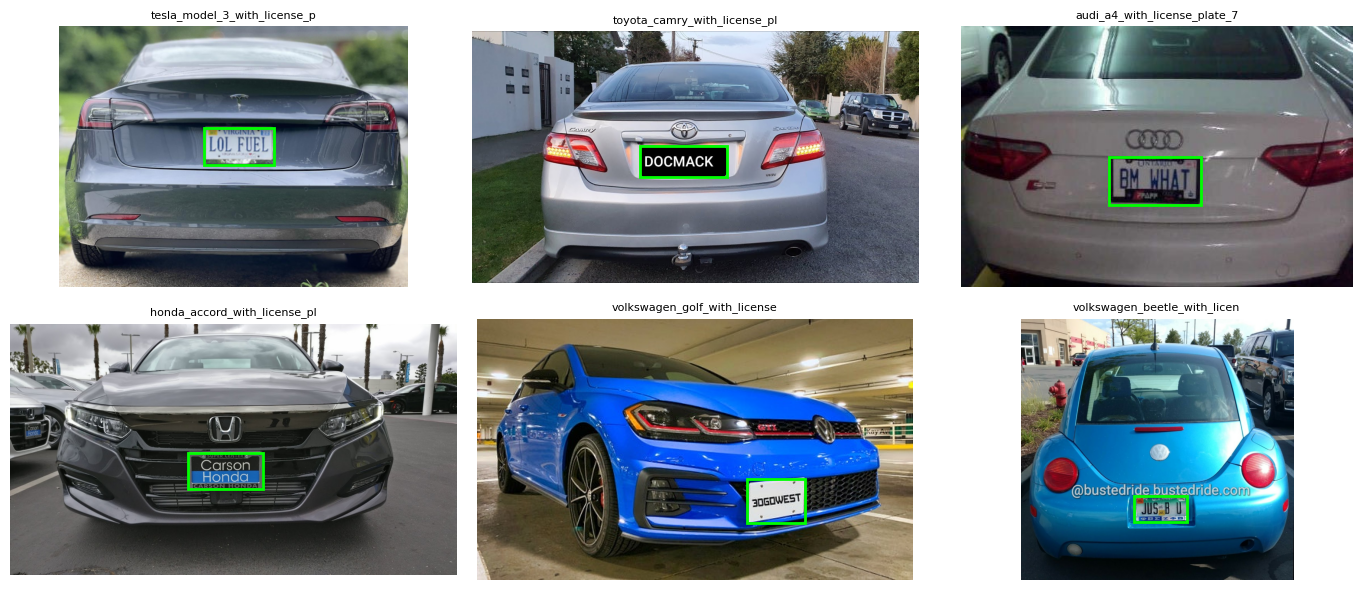

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

from src.data_loader import find_pairs

def show_sample(pairs, n=6, seed=0):
    """Draw label boxes on a few images to confirm the annotations line up."""
    import random

    sample = random.Random(seed).sample(pairs, n)
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for ax, (img_path, lbl_path) in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        ax.imshow(img)
        w, h = img.size
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            # YOLO stores normalised centre + size; matplotlib wants corners.
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h),
                    bw * w,
                    bh * h,
                    fill=False,
                    edgecolor="lime",
                    linewidth=2,
                )
            )
        ax.set_title(img_path.stem[:28], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# show sample
pairs, _, _ = find_pairs(RAW)
show_sample(pairs)

### Split

- Split train/val.
- `LIMIT` caps the number of pairs for a fast smoke run.


In [10]:
from src.data_loader import build_split, verify_split

# e.g. 100 for a fast smoke run
# LIMIT = 100
LIMIT = None  # all images

# split data
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=0))

# raises on unpaired files or train/val leakage
print(verify_split(PROCESSED))

{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


Check the split on disk.

The split is derived from `data/raw` with a fixed seed, so it is reproducible
from the raw data and does not need its own copy in S3.


In [11]:
# count split files
for split in ("train", "val"):
    n_img = len(list((PROCESSED / split / "images").iterdir()))
    n_lbl = len(list((PROCESSED / split / "labels").iterdir()))
    print(f"{split:6} images {n_img:4}  labels {n_lbl:4}")

total_bytes = sum(p.stat().st_size for p in PROCESSED.rglob("*") if p.is_file())
print(f"\n{PROCESSED}  {total_bytes / 1e6:.1f} MB")

train  images  445  labels  445
val    images  111  labels  111

/home/jovyan/kubeflow-yolo/data/processed  204.7 MB


### Dataset configuration file

Write `configs/data.yaml`, which points YOLO at the split and names the classes.


In [12]:
from src.data_loader import write_data_yaml

# get name from classes.txt
names = (RAW / "classes.txt").read_text().split()

# Create data config yaml file
data_yaml = write_data_yaml(ROOT / "train-job" / "configs" / "data.yaml", PROCESSED, names)

print(data_yaml.read_text())

path: /home/jovyan/kubeflow-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Define model

Load the pretrained checkpoint and confirm it lines up with the dataset.

- `yolo11n` is the smallest YOLO11 variant, which matters on a CPU node.


### Training hyperparameters

Loaded from `train-job/configs/train.yaml` — the same file the containerised
training job uses. `device` and `workers` are overridden for this pod.


In [ ]:
from src.train import load_train_cfg

# load hyperparameters from train-job/configs/train.yaml
train_cfg = load_train_cfg(
    ROOT / "train-job" / "configs" / "train.yaml",
    {
        "device": DEVICE,
        "workers": os.cpu_count() or 2,
        "name": "kf-train",
    },
)

# anchor `project` to the repo
train_cfg["project"] = str(ROOT / train_cfg["project"])

train_cfg

In [10]:
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

# Validate dataset; stop id invalid
checked = check_det_dataset(str(data_yaml))
print("dataset ", {k: checked[k] for k in ("nc", "names", "train", "val")})

model = YOLO(train_cfg["model"])

n_params = sum(p.numel() for p in model.model.parameters())
print(f"model    {train_cfg['model']}  {n_params / 1e6:.2f}M params")

# the pretrained head is COCO's 80 classes; ultralytics reshapes it at train time
print(f"classes  pretrained {len(model.names)} -> dataset {checked['nc']} {list(checked['names'].values())}")

dataset  {'nc': 1, 'names': {0: 'car_plate'}, 'train': '/home/sagemaker-user/sagemaker-yolo/data/processed/train/images', 'val': '/home/sagemaker-user/sagemaker-yolo/data/processed/val/images'}
model    yolo26n.pt  2.57M params
classes  pretrained 80 -> dataset 1 ['car_plate']


## Train model

Fine-tune the pretrained checkpoint on the split.

On a 2-CPU pod this takes well over an hour. For a quick smoke test, set
`LIMIT` in the split cell and drop `epochs` before running.


In [ ]:
import time

# `model` is not a train() kwarg; the checkpoint is already loaded
cfg = {k: v for k, v in train_cfg.items() if k != "model"}

print(f"training {train_cfg['model']} for {cfg['epochs']} epochs on {cfg['device']}")

start = time.time()
# train model
results = model.train(data=str(data_yaml), **cfg)
elapsed = time.time() - start

print(f"\nelapsed: {elapsed:.0f}s ({elapsed / 60:.1f} min)")

---

### Training results

Final-epoch metrics on the validation split, and the weights ultralytics kept.

- `best.pt`: the epoch with the highest fitness score; this is what gets exported.
- `last.pt`: the final epoch, for resuming.


In [12]:
# print save dir
save_dir = Path(results.save_dir)
print("save_dir", save_dir)

print()

# print metrics
for key in ("metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"):
    print(f"{key:24} {results.results_dict[key]:.4f}")

print()
# print weighted file
for weight in sorted((save_dir / "weights").glob("*.pt")):
    print(f"{weight.name:10} {weight.stat().st_size / 1e6:.1f} MB")

print()
print("artifacts", sorted(p.name for p in save_dir.iterdir() if p.is_file()))

save_dir /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train

metrics/precision(B)     0.8541
metrics/recall(B)        0.8793
metrics/mAP50(B)         0.9376
metrics/mAP50-95(B)      0.7625

best.pt    5.4 MB
last.pt    5.4 MB

artifacts ['BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'args.yaml', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'labels.jpg', 'results.csv', 'results.png', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch2240.jpg', 'train_batch2241.jpg', 'train_batch2242.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg']


Visualize historical data.


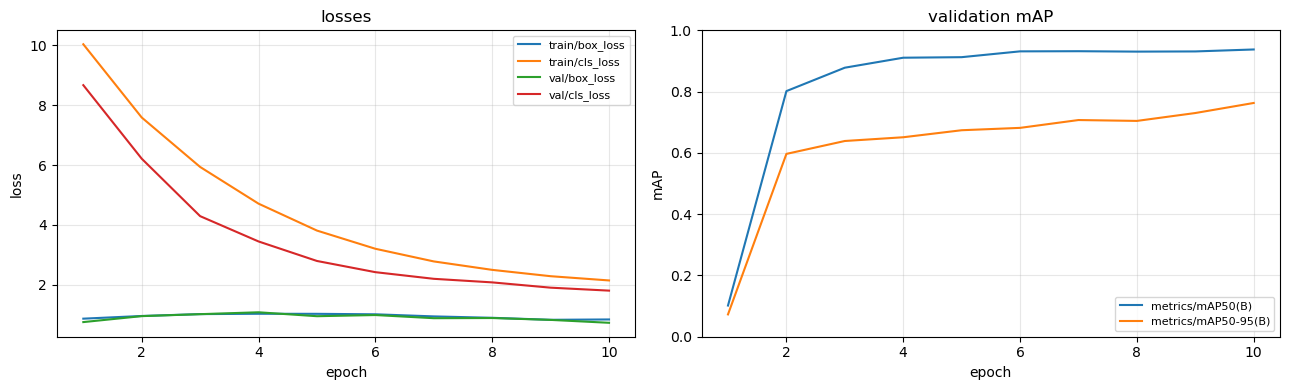

,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
7,8,91.9881,0.89787,2.49976,0.00475,0.85465,0.86173,0.93053,0.70437,0.89022,2.08131,0.00520,0.000614,0.000614,0.000614
8,9,101.2620,0.83093,2.28809,0.00413,0.86578,0.82759,0.93114,0.73009,0.82777,1.90469,0.00455,0.000416,0.000416,0.000416
9,10,110.4150,0.84248,2.14627,0.00417,0.85445,0.87931,0.93753,0.76293,0.73081,1.80596,0.00398,0.000218,0.000218,0.000218


In [13]:
import pandas as pd

history = pd.read_csv(save_dir / "results.csv")
history.columns = history.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for col in ("train/box_loss", "train/cls_loss", "val/box_loss", "val/cls_loss"):
    if col in history:
        axes[0].plot(history["epoch"], history[col], label=col)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("losses")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# still climbing at the last epoch means more epochs would help
for col in ("metrics/mAP50(B)", "metrics/mAP50-95(B)"):
    if col in history:
        axes[1].plot(history["epoch"], history[col], label=col)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("validation mAP")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

history.tail(3)

## Eval model

Re-evaluate `best.pt` on the validation split.


In [14]:
# construct the best model
best = YOLO(str(save_dir / "weights" / "best.pt"))

# get metrics
metrics = best.val(
    data=str(data_yaml),
    imgsz=train_cfg["imgsz"],
    batch=train_cfg["batch"],
    device=train_cfg["device"],
    plots=True,
    project=str(save_dir.parent),
    name=f"{save_dir.name}-val",
    exist_ok=True,
)

# print metrics
print(f"mAP50      {metrics.box.map50:.4f}")
print(f"mAP50-95   {metrics.box.map:.4f}")
print(f"precision  {metrics.box.mp:.4f}")
print(f"recall     {metrics.box.mr:.4f}")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14913MiB)


YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2765.0±1372.6 MB/s, size: 314.9 KB)


val: Scanning /home/sagemaker-user/sagemaker-yolo/data/processed/val/labels.cache... 111 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 111/111 46.6Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 7% ╸─────────── 1/14 1.8it/s 0.2s<7.0s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 7.0it/s 2.0s

                   all        111        116      0.836      0.888      0.935      0.758


Speed: 2.0ms preprocess, 9.1ms inference, 0.0ms loss, 0.1ms postprocess per image


Results saved to /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train-val


mAP50      0.9346
mAP50-95   0.7584
precision  0.8360
recall     0.8879


### Predictions vs fact

- Green = label
- Red = prediction


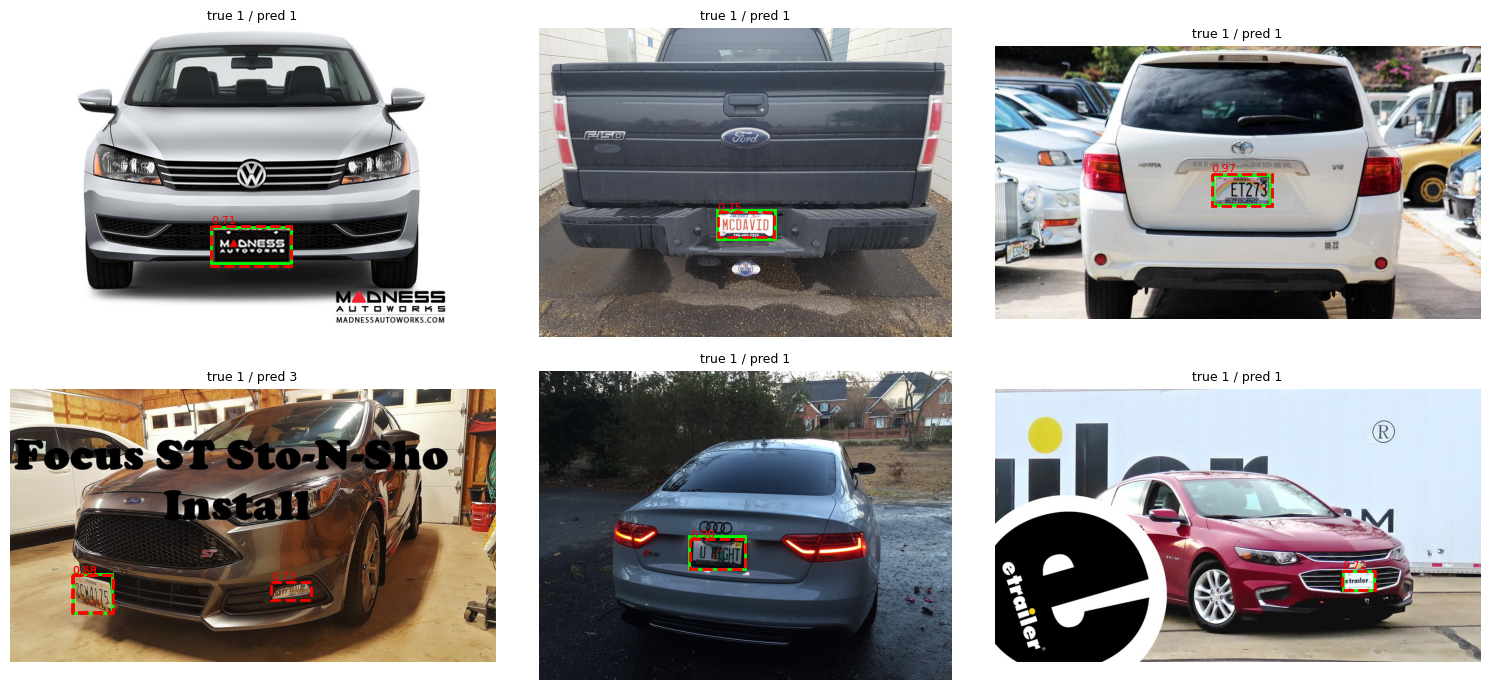

In [15]:
import random


def show_predictions(model, split_dir, n=6, seed=0, conf=0.25):
    """Overlay ground-truth (green) and predicted (red) boxes on val images."""
    images = sorted((split_dir / "images").iterdir())
    sample = random.Random(seed).sample(images, n)

    fig, axes = plt.subplots(2, n // 2, figsize=(15, 7))
    for ax, img_path in zip(axes.ravel(), sample):
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        label_path = split_dir / "labels" / f"{img_path.stem}.txt"
        n_true = 0
        for line in label_path.read_text().splitlines():
            if not line.strip():
                continue
            n_true += 1
            _, cx, cy, bw, bh = (float(v) for v in line.split())
            ax.add_patch(
                plt.Rectangle(
                    ((cx - bw / 2) * w, (cy - bh / 2) * h), bw * w, bh * h,
                    fill=False, edgecolor="lime", linewidth=2,
                )
            )

        # imgsz must match training, or boxes land in the wrong place
        result = model.predict(
            img_path,
            imgsz=train_cfg["imgsz"],
            conf=conf,
            device=train_cfg["device"],
            verbose=False,
        )[0]
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            ax.add_patch(
                plt.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, edgecolor="red", linewidth=2, linestyle="--",
                )
            )
            ax.text(x1, y1 - 4, f"{box.conf.item():.2f}", color="red", fontsize=8)

        ax.set_title(f"true {n_true} / pred {len(result.boxes)}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(best, PROCESSED / "val")

### Missing predictions

List missing predictions


In [16]:
from collections import defaultdict

val_dir = PROCESSED / "val"
images = sorted((val_dir / "images").iterdir())

# Batched rather than one predict() per image — much faster on CPU.
# Chunked to the training batch size to keep memory flat.
batch = train_cfg["batch"]
preds = []
for i in range(0, len(images), batch):
    preds.extend(
        best.predict(
            [str(p) for p in images[i : i + batch]],
            imgsz=train_cfg["imgsz"],
            conf=0.25,
            device=train_cfg["device"],
            verbose=False,
        )
    )

by_true_count = defaultdict(lambda: {"images": 0, "true": 0, "pred": 0, "under": 0})

for img_path, pred in zip(images, preds):
    label_path = val_dir / "labels" / f"{img_path.stem}.txt"
    n_true = len([ln for ln in label_path.read_text().splitlines() if ln.strip()])
    n_pred = len(pred.boxes)

    row = by_true_count[n_true]
    row["images"] += 1
    row["true"] += n_true
    row["pred"] += n_pred
    row["under"] += max(0, n_true - n_pred)

print(f"{'plates/img':>11} {'images':>7} {'labelled':>9} {'detected':>9} {'missed':>7}")
for n_true in sorted(by_true_count):
    r = by_true_count[n_true]
    print(f"{n_true:>11} {r['images']:>7} {r['true']:>9} {r['pred']:>9} {r['under']:>7}")

total_true = sum(r["true"] for r in by_true_count.values())
total_missed = sum(r["under"] for r in by_true_count.values())
print(f"\nmissed {total_missed}/{total_true} plates ({total_missed / total_true:.1%})")

 plates/img  images  labelled  detected  missed
          1     106       106       119       6
          2       5        10         6       4

missed 10/116 plates (8.6%)


### Evaluation plots

Visualize metrics


confusion_matrix_normalized.png


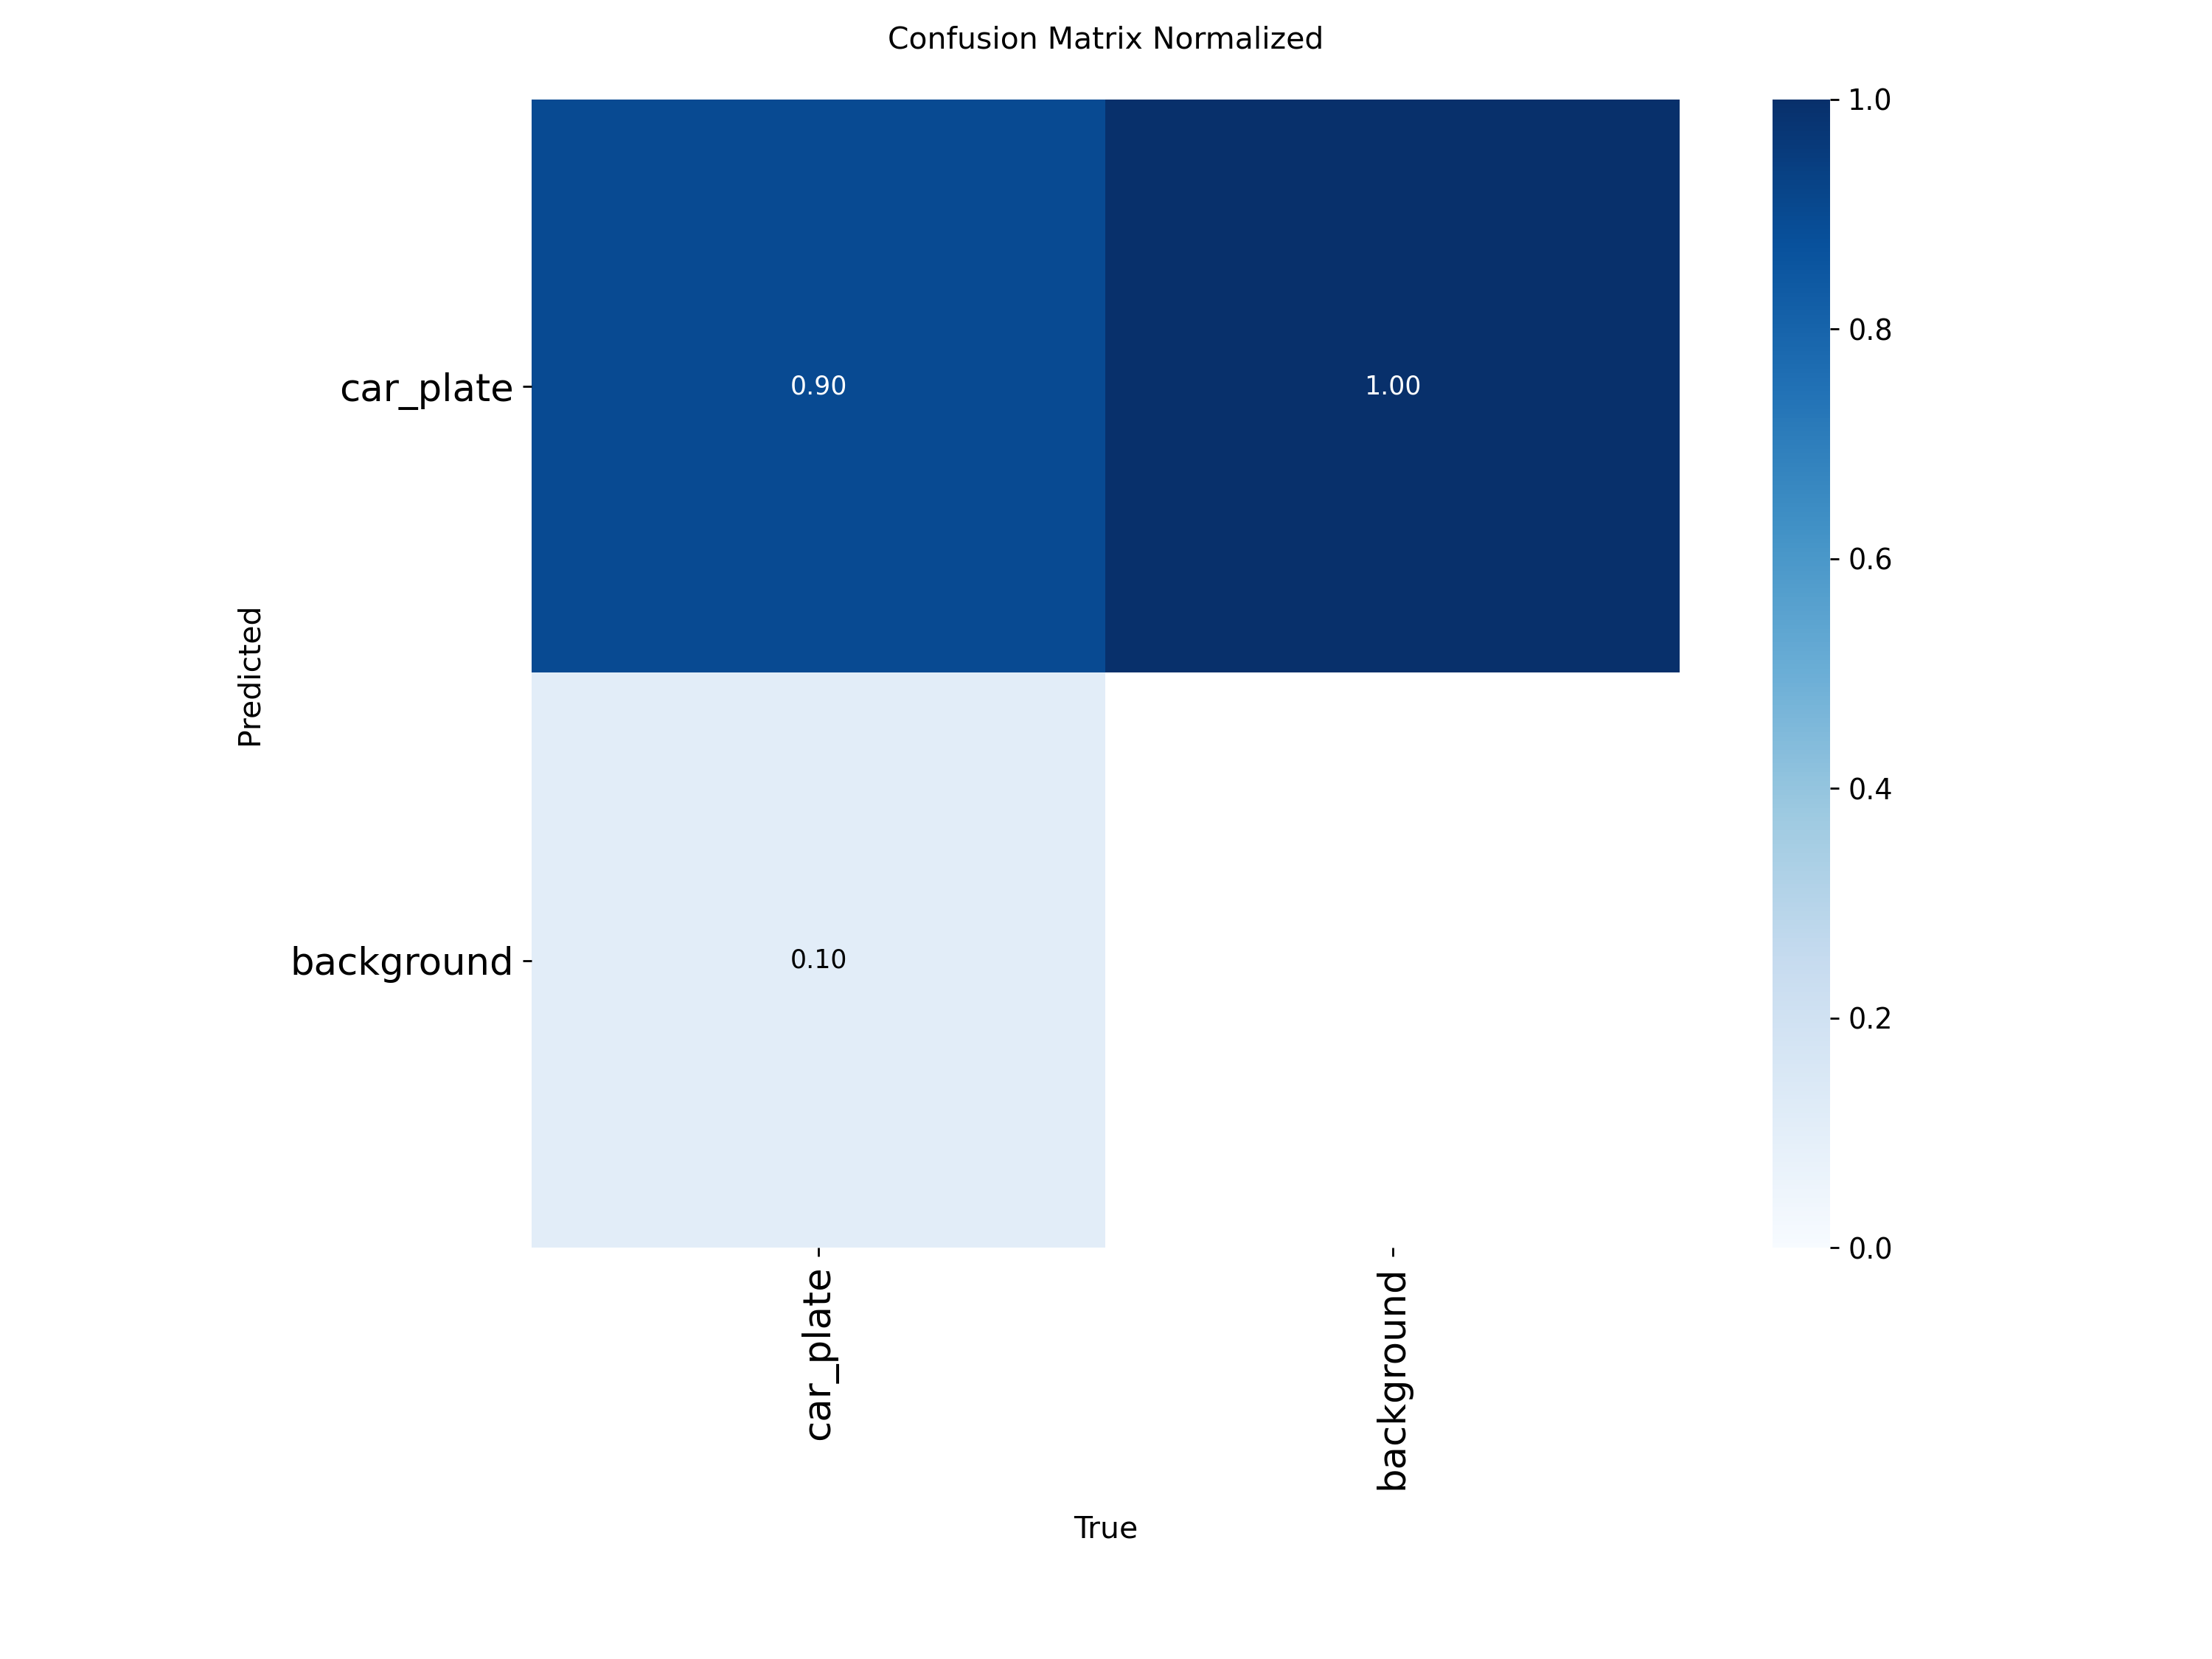

In [17]:
from IPython.display import Image as IPyImage, display

val_dir_out = Path(metrics.save_dir)

for plot in ("PR_curve.png", "confusion_matrix_normalized.png"):
    path = val_dir_out / plot
    if path.exists():
        print(path.name)
        display(IPyImage(filename=str(path), width=560))

## Export model

Export `best.pt` to ONNX and upload it to S3.


In [18]:
import shutil

# export model
exported = Path(best.export(format="onnx", imgsz=train_cfg["imgsz"], opset=12, simplify=True))
n_train = len(list((PROCESSED / "train" / "images").iterdir()))

# export path
onnx_path = MODELS / (
    f"{train_cfg['name']}-{device_tag}-{n_train}img-{train_cfg['imgsz']}px-{train_cfg['epochs']}ep.onnx"
)
shutil.move(str(exported), onnx_path)

print(onnx_path.name)
print(f"{onnx_path.stat().st_size / 1e6:.1f} MB")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8259CL CPU @ 2.50GHz)



PyTorch: starting from '/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)



ONNX: starting export with onnx 1.22.0 opset 12...


ONNX: slimming with onnxslim 0.1.95...


2026-08-15 03:45:56.696979134 [W:onnxruntime:Default, device_discovery.cc:285 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:94 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 1.6s, saved as '/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx' (9.4 MB)



Export complete (1.9s)
Results saved to /home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx
Predict:         yolo predict task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/sagemaker-train/weights/best.onnx imgsz=640 data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml  
Visualize:       https://netron.app


sagemaker-train-gpu-445img-640px-10ep.onnx
9.8 MB


Write a metadata file that contrains the input size and classes.


In [19]:
import json
from datetime import datetime, timezone

sidecar = onnx_path.with_suffix(".metadata.json")
sidecar.write_text(json.dumps({
    "imgsz": train_cfg["imgsz"],
    "names": [best.names[i] for i in sorted(best.names)],
    "metrics": {
        "mAP50": round(metrics.box.map50, 4),
        "mAP50-95": round(metrics.box.map, 4),
        "precision": round(metrics.box.mp, 4),
        "recall": round(metrics.box.mr, 4),
    },
    "train": {k: train_cfg[k] for k in ("model", "epochs", "batch", "seed")},
    "images": n_images,
    "exported_at": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(sidecar.read_text())

{
  "imgsz": 640,
  "names": [
    "car_plate"
  ],
  "metrics": {
    "mAP50": 0.9346,
    "mAP50-95": 0.7584,
    "precision": 0.836,
    "recall": 0.8879
  },
  "train": {
    "model": "yolo26n.pt",
    "epochs": 10,
    "batch": 8,
    "seed": 0
  },
  "images": 556,
  "exported_at": "2026-08-15T03:45:57.469938+00:00"
}


Bundle the ONNX model, its metadata, and the trained weights into `model.tar.gz`
and upload it to S3.


In [ ]:
import tarfile

bundle = MODELS / "model.tar.gz"
members = [onnx_path, sidecar, save_dir / "weights" / "best.pt"]

# flat archive.
with tarfile.open(bundle, "w:gz") as tar:
    for path in members:
        tar.add(path, arcname=path.name)

raw_bytes = sum(p.stat().st_size for p in members)
print(bundle.name)
print(f"{raw_bytes / 1e6:.1f} MB  ->  {bundle.stat().st_size / 1e6:.1f} MB")
with tarfile.open(bundle) as tar:
    for name in tar.getnames():
        print(f"  {name}")

# one prefix per model, since every bundle is named model.tar.gz by convention
prefix = f"models/{onnx_path.stem}"
key = f"{prefix}/{bundle.name}"

# upload
s3.upload_file(str(bundle), BUCKET, key)
print(f"\ns3://{BUCKET}/{key}")

print()
listed = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix).get("Contents", [])
for obj in sorted(listed, key=lambda o: o["Key"]):
    print(f"  {obj['Size'] / 1e6:>6.1f} MB  {obj['Key'].rsplit('/', 1)[-1]}")